# DATA CLEANING

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("datasets/train.csv")


In [4]:
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
columns = df.columns
print(columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [6]:
# Rows and columns
df.shape

(891, 12)

In [7]:
# information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
df.describe()
# df["Age"].mean()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

29.69911764705882
28.0
0.42
80.0
Axes(0.125,0.11;0.775x0.77)


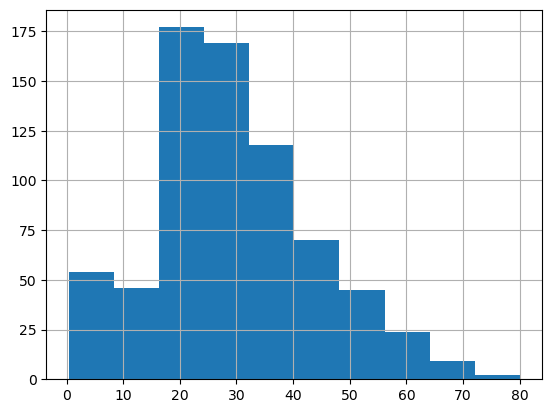

In [11]:
print(df['Age'].mean())
print(df['Age'].median())
print(df['Age'].min())
print(df['Age'].max())
print(df['Age'].hist())



In [12]:
df.groupby("Pclass")["Age"].median()

Pclass
1    37.0
2    29.0
3    24.0
Name: Age, dtype: float64

In [13]:
df.groupby("Sex")["Age"].median()


Sex
female    27.0
male      29.0
Name: Age, dtype: float64

In [14]:
df.groupby(["Pclass", "Sex"])["Age"].median()


Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

In [15]:
df['Age'] = df['Age'].fillna(df.groupby(['Pclass', "Sex"])["Age"].transform("median"))

In [16]:
df["Age"].isnull().sum()

np.int64(0)

In [17]:
df["Cabin"].notna().groupby(df["Survived"]).mean()

Survived
0    0.123862
1    0.397661
Name: Cabin, dtype: float64

In [18]:
df.groupby("Survived")["Cabin"].apply(lambda x: x.notna().mean())

Survived
0    0.123862
1    0.397661
Name: Cabin, dtype: float64

In [19]:
df["HasCabin"] = df["Cabin"].notna().astype(int)
df.groupby("HasCabin")["Survived"].mean()

HasCabin
0    0.299854
1    0.666667
Name: Survived, dtype: float64

In [20]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [21]:
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [22]:
df.groupby("Embarked")["Survived"].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

In [23]:
pd.crosstab(df["Sex"], df["Pclass"], values=df["Survived"], aggfunc="mean")

Pclass,1,2,3
Sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


In [24]:
df.groupby(pd.cut(df["Age"], bins=[0,12,18,35,60,100]))["Survived"].mean()

C:\Users\anmol\AppData\Local\Temp\ipykernel_4132\4255032903.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df["Age"], bins=[0,12,18,35,60,100]))["Survived"].mean()


Age
(0, 12]      0.579710
(12, 18]     0.428571
(18, 35]     0.357977
(35, 60]     0.384259
(60, 100]    0.227273
Name: Survived, dtype: float64

In [25]:
pd.pivot_table(
    df,
    values="Survived",
    index="Sex",
    columns="Pclass",
    aggfunc="mean"
)

Pclass,1,2,3
Sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


In [26]:
pd.pivot_table(
    df,
    values="Survived",
    index="Sex",
    columns=pd.cut(df["Age"], bins=[0,12,18,35,60,100]),
    aggfunc="mean"
)

C:\Users\anmol\AppData\Local\Temp\ipykernel_4132\2266739005.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(


Age,"(0, 12]","(12, 18]","(18, 35]","(35, 60]","(60, 100]"
Sex,,,,,
female,0.593750,0.750000,0.751445,0.771429,1.000000
male,0.567568,0.088235,0.158358,0.198630,0.105263


In [27]:
df["Fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

<Axes: >

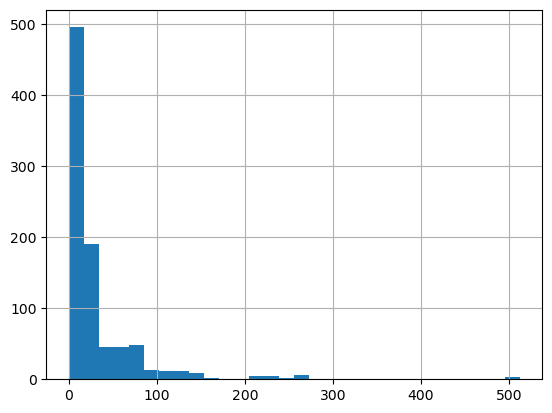

In [28]:
df["Fare"].hist(bins=30)

In [29]:
df.groupby(pd.qcut(df["Fare"], 4))["Survived"].mean()

C:\Users\anmol\AppData\Local\Temp\ipykernel_4132\1256130791.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df["Fare"], 4))["Survived"].mean()


Fare
(-0.001, 7.91]     0.197309
(7.91, 14.454]     0.303571
(14.454, 31.0]     0.454955
(31.0, 512.329]    0.581081
Name: Survived, dtype: float64

In [30]:
df.groupby("Pclass")["Fare"].mean()

Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

In [31]:
df.groupby("Embarked")["Survived"].mean()

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

In [32]:
pd.crosstab(df["Embarked"], df["Pclass"])

Pclass,1,2,3
Embarked,,,
C,85,17,66
Q,2,3,72
S,127,164,353


In [33]:
df.groupby("SibSp")["Survived"].mean()

SibSp
0    0.345395
1    0.535885
2    0.464286
3    0.250000
4    0.166667
5    0.000000
8    0.000000
Name: Survived, dtype: float64

In [34]:
df.groupby("Parch")["Survived"].mean()

Parch
0    0.343658
1    0.550847
2    0.500000
3    0.600000
4    0.000000
5    0.200000
6    0.000000
Name: Survived, dtype: float64

In [35]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

In [36]:
df["FamilySize"].value_counts().sort_index()

FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

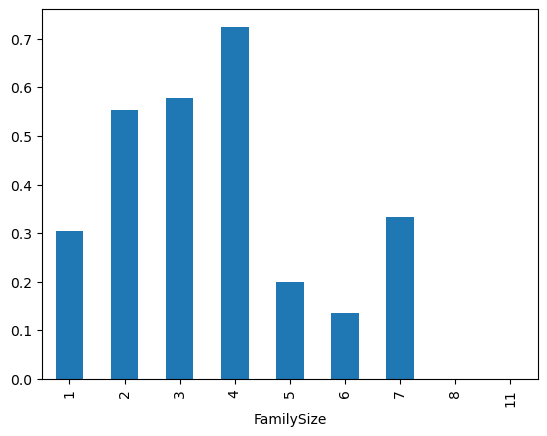

In [37]:
df.groupby("FamilySize")["Survived"].mean().plot(kind="bar")
plt.show()

In [38]:
df.groupby("FamilySize")["Survived"].mean()


FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

In [39]:
df["FamilySize"].value_counts().sort_index()

FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

In [40]:
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

In [41]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  HasCabin     891 non-null    int64  
 13  FamilySize   891 non-null    int64  
 14  IsAlone      891 non-null    int64  
dtypes: float64(2), int64(8), object(5)
memory usage: 104.5+ KB


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
HasCabin         0
FamilySize       0
IsAlone          0
dtype: int64

In [42]:
df = df.drop("Cabin", axis=1)

In [43]:
df["Embarked"].mode()

0    S
Name: Embarked, dtype: object

In [44]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [45]:
df = df.drop("PassengerId", axis=1)

In [46]:
df = df.drop("Name", axis=1)

In [47]:
df = df.drop("Ticket", axis=1)

In [48]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    object 
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked    891 non-null    object 
 8   HasCabin    891 non-null    int64  
 9   FamilySize  891 non-null    int64  
 10  IsAlone     891 non-null    int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 76.7+ KB


Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked      0
HasCabin      0
FamilySize    0
IsAlone       0
dtype: int64

Key Findings:
- Females had much higher survival rates than males.
- First-class passengers survived more often than third-class passengers.
- Higher fare passengers survived more often.
- Passengers with cabin information survived more often.
- Small families (2–4 members) had the highest survival rates.
- Children survived more often than adults.
- Cherbourg passengers showed higher survival rates, likely due to a larger proportion of first-class passengers.

### MACHINE LEARNING MODEL WORK


In [49]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [50]:
df = pd.get_dummies(
    df,
    columns=["Sex", "Embarked"],
    drop_first=True
)

In [51]:
y = df["Survived"]
X = df.drop("Survived", axis=1)

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [53]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,HasCabin,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,0,2,0,True,False,True
1,1,1,38.0,1,0,71.2833,1,2,0,False,False,False
2,1,3,26.0,0,0,7.9250,0,1,1,False,False,True
3,1,1,35.0,1,0,53.1000,1,2,0,False,False,True
4,0,3,35.0,0,0,8.0500,0,1,1,True,False,True


In [54]:
X_train.shape


(712, 11)

In [55]:
X_test.shape

(179, 11)

In [56]:
X.columns

Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin', 'FamilySize',
       'IsAlone', 'Sex_male', 'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [57]:
model = LogisticRegression(max_iter=1000)

In [58]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [59]:
X.dtypes

Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
HasCabin        int64
FamilySize      int64
IsAlone         int64
Sex_male         bool
Embarked_Q       bool
Embarked_S       bool
dtype: object

In [60]:
predictions = model.predict(X_test)

In [61]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.8100558659217877


In [62]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

print(cm)

[[91 14]
 [20 54]]


In [63]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.82      0.87      0.84       105
           1       0.79      0.73      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [64]:
predictions = model.predict(X_test)

from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, predictions))

0.8100558659217877


In [65]:
for feature, coef in zip(X.columns, model.coef_[0]):
    print(feature, coef)

Pclass -0.7763294091585217
Age -0.032588121712399984
SibSp -0.20942637728735086
Parch -0.00465694710447453
Fare 0.0015366445890315846
HasCabin 0.5557758173299375
FamilySize -0.2458582295029031
IsAlone -0.604230540945699
Sex_male -2.5232315258015348
Embarked_Q -0.13688191646396128
Embarked_S -0.32318854834563226


In [66]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, predictions))

[[91 14]
 [20 54]]


### DECISION TREE CLASSIFIER


In [67]:
from sklearn.tree import DecisionTreeClassifier
# from sklearn.ensemble import RandomForestClassifier

In [68]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.82      0.87      0.84       105
           1       0.79      0.73      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [69]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

In [70]:
from sklearn.metrics import accuracy_score

print("Decision Tree Accuracy:",
      accuracy_score(y_test, pred_dt))

Decision Tree Accuracy: 0.7821229050279329


In [71]:
for feature, importance in zip(X.columns, dt.feature_importances_):
    print(feature, importance)

Pclass 0.10186517487522907
Age 0.20832332304255993
SibSp 0.03702599926051674
Parch 0.013491317700418736
Fare 0.2269610144003023
HasCabin 0.03658766776238367
FamilySize 0.04706636943338205
IsAlone 0.0
Sex_male 0.30700857920355257
Embarked_Q 0.00730232565927727
Embarked_S 0.014368228662377773


In [72]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [73]:
print(
    "Random Forest Accuracy:",
    accuracy_score(y_test, pred_rf)
)

Random Forest Accuracy: 0.8268156424581006


In [74]:
for feature, importance in zip(X.columns, rf.feature_importances_):
    print(feature, importance)

Pclass 0.06895022009323258
Age 0.24720382722749887
SibSp 0.028854725682491155
Parch 0.023118573170101943
Fare 0.24870013251723277
HasCabin 0.03662861375218038
FamilySize 0.04721154037344308
IsAlone 0.010585924895887945
Sex_male 0.25308074538566344
Embarked_Q 0.010411854621431118
Embarked_S 0.02525384228083671


In [75]:
from sklearn.metrics import accuracy_score

print("Logistic Regression:",
      accuracy_score(y_test, predictions))

print("Decision Tree:",
      accuracy_score(y_test, pred_dt))

print("Random Forest:",
      accuracy_score(y_test, pred_rf))

Logistic Regression: 0.8100558659217877
Decision Tree: 0.7821229050279329
Random Forest: 0.8268156424581006


In [76]:
for feature, importance in zip(X.columns, rf.feature_importances_):
    print(feature, round(importance, 4))

Pclass 0.069
Age 0.2472
SibSp 0.0289
Parch 0.0231
Fare 0.2487
HasCabin 0.0366
FamilySize 0.0472
IsAlone 0.0106
Sex_male 0.2531
Embarked_Q 0.0104
Embarked_S 0.0253


# EDA

In [80]:
df_eda = pd.read_csv("datasets/train.csv")

In [81]:
df_eda.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [82]:
df_eda["HasCabin"] = df_eda["Cabin"].notnull().astype(int)

df_eda["FamilySize"] = (
    df_eda["SibSp"]
    + df_eda["Parch"]
    + 1
)

df_eda["IsAlone"] = (
    df_eda["FamilySize"] == 1
).astype(int)

In [83]:
age_medians = (
    df_eda.groupby(["Pclass","Sex"])["Age"]
    .median()
)

for (pclass, sex), median_age in age_medians.items():
    
    mask = (
        (df_eda["Pclass"] == pclass)
        &
        (df_eda["Sex"] == sex)
        &
        (df_eda["Age"].isnull())
    )

    df_eda.loc[mask, "Age"] = median_age

In [84]:
df_eda["Embarked"] = df_eda["Embarked"].fillna(
    df_eda["Embarked"].mode()[0]
)

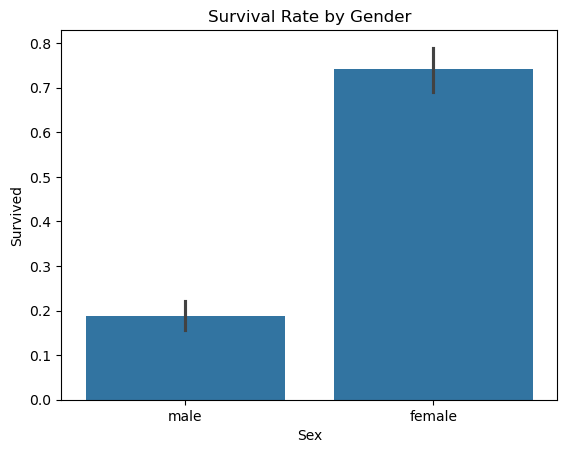

In [85]:
sns.barplot(
    x="Sex",
    y="Survived",
    data=df_eda
)

plt.title("Survival Rate by Gender")

plt.savefig(
    "gender_survival.png",
    bbox_inches="tight"
)

plt.show()

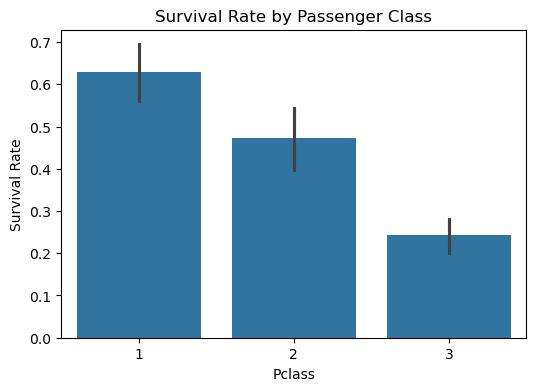

In [87]:
plt.figure(figsize=(6,4))

sns.barplot(
    x="Pclass",
    y="Survived",
    data=df_eda
)

plt.title("Survival Rate by Passenger Class")
plt.ylabel("Survival Rate")

plt.savefig(
    "pclass_survival.png",
    bbox_inches="tight"
)

plt.show()

C:\Users\anmol\AppData\Local\Temp\ipykernel_4132\1425187226.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_eda.groupby("FareGroup")["Survived"]


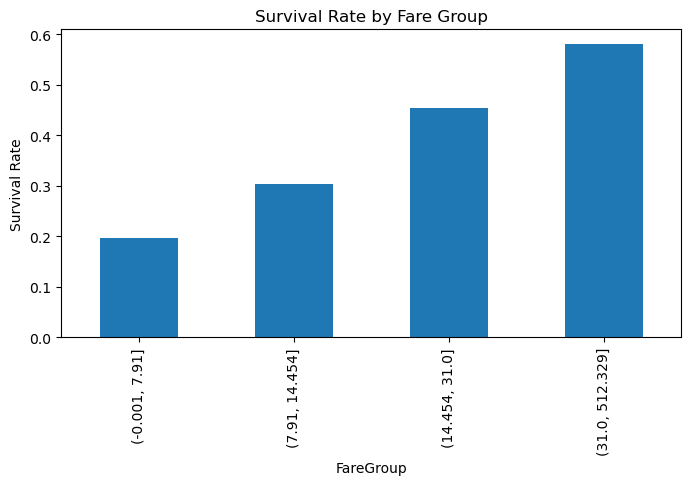

In [88]:
df_eda["FareGroup"] = pd.qcut(
    df_eda["Fare"],
    q=4
)

fare_survival = (
    df_eda.groupby("FareGroup")["Survived"]
    .mean()
)

plt.figure(figsize=(8,4))

fare_survival.plot(
    kind="bar"
)

plt.title("Survival Rate by Fare Group")
plt.ylabel("Survival Rate")

plt.savefig(
    "fare_survival.png",
    bbox_inches="tight"
)

plt.show()

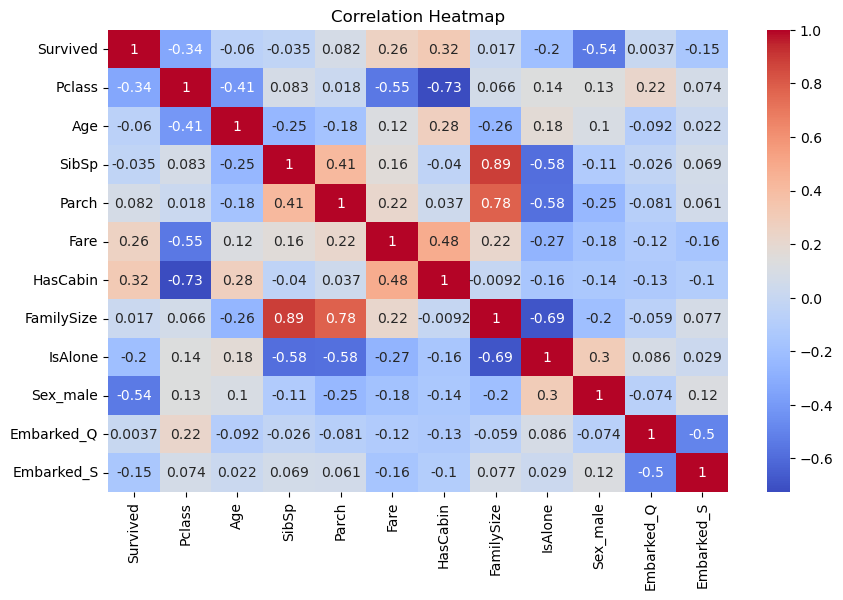

In [89]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "correlation_heatmap.png",
    bbox_inches="tight"
)

plt.show()

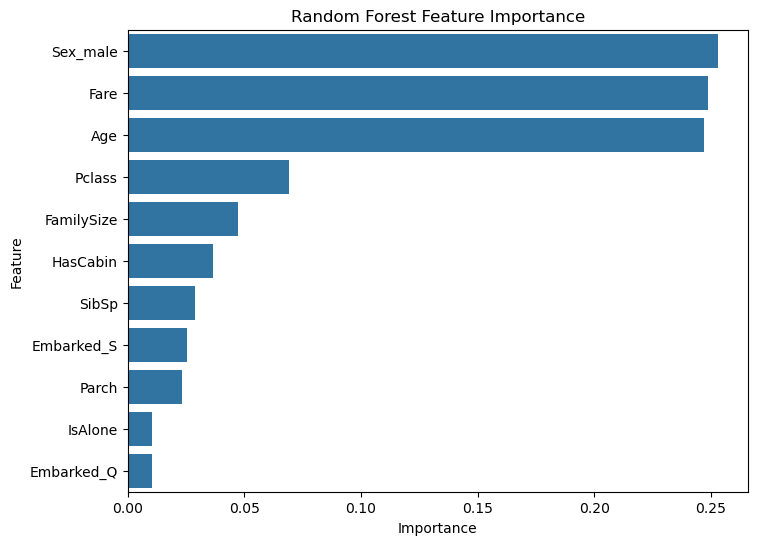

In [90]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df
)

plt.title("Random Forest Feature Importance")

plt.savefig(
    "feature_importance.png",
    bbox_inches="tight"
)

plt.show()

In [91]:
import os

os.makedirs("images", exist_ok=True)

In [92]:
plt.savefig(
    "images/gender_survival.png",
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

# KAGGLE SUBMISSION FILE GENERATION

In [93]:
import pandas as pd

# =====================================
# LOAD TEST DATA
# =====================================

test_df = pd.read_csv("datasets/test.csv")

# =====================================
# FEATURE ENGINEERING
# =====================================

# HasCabin
test_df["HasCabin"] = test_df["Cabin"].notnull().astype(int)

# FamilySize
test_df["FamilySize"] = (
    test_df["SibSp"]
    + test_df["Parch"]
    + 1
)

# IsAlone
test_df["IsAlone"] = (
    test_df["FamilySize"] == 1
).astype(int)

# =====================================
# FILL MISSING AGE VALUES
# =====================================

age_fill = {
    (1, "female"): 35.0,
    (1, "male"): 40.0,
    (2, "female"): 28.0,
    (2, "male"): 30.0,
    (3, "female"): 21.5,
    (3, "male"): 25.0
}

for (pclass, sex), age in age_fill.items():

    mask = (
        (test_df["Pclass"] == pclass)
        & (test_df["Sex"] == sex)
        & (test_df["Age"].isnull())
    )

    test_df.loc[mask, "Age"] = age

# =====================================
# FILL MISSING FARE VALUES
# =====================================

test_df["Fare"] = test_df["Fare"].fillna(
    test_df["Fare"].median()
)

# =====================================
# ONE HOT ENCODING
# =====================================

test_df = pd.get_dummies(
    test_df,
    columns=["Sex", "Embarked"],
    drop_first=True
)

# =====================================
# ENSURE ALL REQUIRED COLUMNS EXIST
# =====================================

required_cols = [
    "Pclass",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "HasCabin",
    "FamilySize",
    "IsAlone",
    "Sex_male",
    "Embarked_Q",
    "Embarked_S"
]

for col in required_cols:
    if col not in test_df.columns:
        test_df[col] = 0

# =====================================
# CREATE FINAL TEST DATASET
# =====================================

X_kaggle = test_df[required_cols]

# =====================================
# MAKE PREDICTIONS
# =====================================

predictions = rf.predict(X_kaggle)

# =====================================
# CREATE SUBMISSION FILE
# =====================================

submission = pd.DataFrame({
    "PassengerId": test_df["PassengerId"],
    "Survived": predictions
})

# =====================================
# SAVE CSV
# =====================================

submission.to_csv(
    "submission.csv",
    index=False
)

print("submission.csv created successfully!")
print()
print(submission.head())

submission.csv created successfully!

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         1
4          896         0


# POWER BI EDA CLEANED CSV GENERATION

In [2]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("datasets/train.csv")

# -----------------------------
# Handle Missing Values
# -----------------------------

# Fill Embarked with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Fill Fare with median (good practice)
df['Fare'].fillna(df['Fare'].median(), inplace=True)

# Fill Age using Sex + Pclass median
df['Age'] = df.groupby(['Sex', 'Pclass'])['Age'].transform(
    lambda x: x.fillna(x.median())
)

# Remaining Age nulls (if any)
df['Age'].fillna(df['Age'].median(), inplace=True)

# -----------------------------
# Feature Engineering
# -----------------------------

# Family Size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Is Alone
df['IsAlone'] = np.where(df['FamilySize'] == 1, 'Yes', 'No')

# Has Cabin
df['HasCabin'] = np.where(df['Cabin'].isnull(), 'No', 'Yes')

# Age Groups
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 18, 35, 60, 100],
    labels=['Child', 'Young Adult', 'Adult', 'Senior']
)

# -----------------------------
# Optional: Drop unwanted columns
# -----------------------------

df.drop(['Cabin'], axis=1, inplace=True)

# -----------------------------
# Save cleaned dataset
# -----------------------------

df.to_csv("datasets/titanic_cleaned.csv", index=False)

print("Cleaned dataset saved as titanic_cleaned.csv")
print(df.isnull().sum())

Cleaned dataset saved as titanic_cleaned.csv
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
FamilySize     0
IsAlone        0
HasCabin       0
AgeGroup       0
dtype: int64


C:\Users\anmol\AppData\Local\Temp\ipykernel_20372\605919495.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
C:\Users\anmol\AppData\Local\Temp\ipykernel_20372\605919495.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a c